# 🤖 Phase 2: Hybrid Model Training
## MovieLens 20M — Advanced Hybrid Recommender System
### ✅ Python 3.13 + Windows — Zero compilation required

| # | Component | Algorithm | Est. Time |
|---|-----------|----------|-----------|
| 1 | **Matrix Factorization** | FunkSVD (vectorised SGD) | ~10 min |
| 2 | **Bayesian Personalized Ranking** | BPR (cornac) | ~2 min |
| 3 | **Content-Based** | TF-IDF + Cosine | ~20 sec |
| 4 | **Neural CF** | Lightweight NeuMF | ~5 min |
| 5 | **Hybrid Ensemble** | Weighted blend | ~1 min |

## 0. Imports & Setup

In [11]:
import os, sys, json, logging, warnings, yaml
from pathlib import Path

import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
import plotly.express as px
from tqdm.notebook import tqdm
import joblib

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

import cornac                                       # pip install cornac — prebuilt wheel for Python 3.13 Windows
from cornac.models import BPR
from cornac.data import Dataset as CornacDataset

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, callbacks

warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
tf.get_logger().setLevel('ERROR')
np.random.seed(42)
tf.random.set_seed(42)

# ── Paths ──────────────────────────────────────────────────────────
NOTEBOOK_DIR = Path().absolute()
PROJECT_ROOT = NOTEBOOK_DIR.parent
PROC_DIR     = PROJECT_ROOT / 'data' / 'processed'
MODEL_DIR    = PROJECT_ROOT / 'data' / 'models'
LOG_DIR      = PROJECT_ROOT / 'logs'
MODEL_DIR.mkdir(parents=True, exist_ok=True)

with open(PROJECT_ROOT / 'utils' / 'config' / 'config.yaml') as f:
    CFG = yaml.safe_load(f)

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s  %(levelname)s  %(message)s',
    handlers=[
        logging.FileHandler(LOG_DIR / 'phase2_training.log'),
        logging.StreamHandler(sys.stdout)
    ]
)
log = logging.getLogger(__name__)
log.info('Phase 2 ready  |  TF %s  |  cornac %s', tf.__version__, cornac.__version__)

2026-03-07 14:22:15,282  INFO  Phase 2 ready  |  TF 2.20.0  |  cornac 2.3.5


## 1. Load Processed Data

In [3]:
train_df    = pd.read_parquet(PROC_DIR / 'train.parquet')
val_df      = pd.read_parquet(PROC_DIR / 'val.parquet')
test_df     = pd.read_parquet(PROC_DIR / 'test.parquet')
content_df  = pd.read_parquet(PROC_DIR / 'content_docs.parquet')
movie_feats = pd.read_parquet(PROC_DIR / 'movie_features.parquet')
ratings_all = pd.read_parquet(PROC_DIR / 'ratings_clean.parquet')

with open(PROC_DIR / 'encoders.json') as f:
    enc = json.load(f)

N_USERS   = enc['n_users']
N_MOVIES  = enc['n_movies']
user2idx  = {int(k): v for k, v in enc['user2idx'].items()}
movie2idx = {int(k): v for k, v in enc['movie2idx'].items()}
idx2movie = {int(k): v for k, v in enc['idx2movie'].items()}

# Arrays for fast access later
u_tr = train_df['user_idx'].values.astype('int32')
m_tr = train_df['movie_idx'].values.astype('int32')
r_tr = train_df['rating'].values.astype('float32')
u_vl = val_df['user_idx'].values.astype('int32')
m_vl = val_df['movie_idx'].values.astype('int32')
r_vl = val_df['rating'].values.astype('float32')
u_te = test_df['user_idx'].values.astype('int32')
m_te = test_df['movie_idx'].values.astype('int32')
r_te = test_df['rating'].values.astype('float32')

log.info('Train=%d Val=%d Test=%d Users=%d Movies=%d',
         len(train_df), len(val_df), len(test_df), N_USERS, N_MOVIES)
print(f'Loaded. Train={len(train_df):,}  Val={len(val_df):,}  Test={len(test_df):,}')
print(f'Users={N_USERS:,}   Movies={N_MOVIES:,}')

2026-03-07 14:14:39,726  INFO  Train=16087404 Val=1938295 Test=1938295 Users=138450 Movies=15446
Loaded. Train=16,087,404  Val=1,938,295  Test=1,938,295
Users=138,450   Movies=15,446


## 2. Component 1 — Biased Matrix Factorization (FunkSVD)
Pure NumPy biased SGD — same algorithm as `surprise.SVD`, no C extensions.

In [12]:
class FunkSVD:
    """
    Biased Matrix Factorization via vectorised SGD.
    
    Key optimisation over naive NumPy:
      - np.add.at (unbuffered, slow) is replaced with scipy sparse
        scatter-add: build a sparse delta matrix each chunk and do
        a single sparse @ dense multiply — 20-50x faster.
      - RMSE tracked on a fixed 50k sample — never touches full array.
      - All predictions chunked — no OOM on large candidate sets.
    """
    def __init__(self, n_factors=150, n_epochs=20, lr=0.005, reg=0.02,
                 random_state=42, rmse_sample=50_000, chunk=65536):
        self.n_factors   = n_factors
        self.n_epochs    = n_epochs
        self.lr          = lr
        self.reg         = reg
        self.rs          = random_state
        self.rmse_sample = rmse_sample
        self.chunk       = chunk
        self.history     = {'train_rmse': [], 'val_rmse': []}

    def fit(self, u_idx, m_idx, ratings, val_u=None, val_m=None, val_r=None):
        import scipy.sparse as sp_local
        rng  = np.random.default_rng(self.rs)
        n_u  = int(u_idx.max()) + 1
        n_m  = int(m_idx.max()) + 1
        k    = self.n_factors
        lr   = np.float32(self.lr)
        reg  = np.float32(self.reg)

        self.P  = rng.normal(0, 0.01, (n_u, k)).astype('float32')
        self.Q  = rng.normal(0, 0.01, (n_m, k)).astype('float32')
        self.bu = np.zeros(n_u, dtype='float32')
        self.bi = np.zeros(n_m, dtype='float32')
        self.mu = np.float32(ratings.mean())

        # Fixed sample for RMSE — avoids allocating 6 GB on full set
        si      = rng.choice(len(ratings), size=min(self.rmse_sample, len(ratings)), replace=False)
        u_s, m_s, r_s = u_idx[si], m_idx[si], ratings[si]

        C = self.chunk

        for epoch in range(self.n_epochs):
            perm           = rng.permutation(len(ratings))
            u_ep, m_ep, r_ep = u_idx[perm], m_idx[perm], ratings[perm]

            for s in range(0, len(r_ep), C):
                u = u_ep[s:s+C]; m = m_ep[s:s+C]; r = r_ep[s:s+C]

                # Forward pass
                Pu = self.P[u]   # (batch, k)
                Qm = self.Q[m]   # (batch, k)
                pred = self.mu + self.bu[u] + self.bi[m] + (Pu * Qm).sum(1)
                err  = (r - pred).astype('float32')  # (batch,)

                # Bias updates (safe — no duplicate issue)
                self.bu[u] += lr * (err - reg * self.bu[u])
                self.bi[m] += lr * (err - reg * self.bi[m])

                # Factor updates via sparse scatter-add
                # dP[u] = lr * (err * Qm  - reg * Pu)
                # dQ[m] = lr * (err * Pu  - reg * Qm)
                # Build sparse weight matrix W: W[i,j] = sum of err[t]
                # where u[t]==i and m[t]==j — then dP = W @ Q, dQ = W.T @ P
                batch = len(u)
                ones  = np.ones(batch, dtype='float32')

                # Sparse matrix: shape (n_u, batch), entry (u[t], t) = err[t]
                W_u = sp_local.csr_matrix(
                    (err, (u, np.arange(batch))), shape=(n_u, batch)
                )
                # Sparse matrix: shape (n_m, batch), entry (m[t], t) = err[t]
                W_m = sp_local.csr_matrix(
                    (err, (m, np.arange(batch))), shape=(n_m, batch)
                )

                # dP = lr * (W_u @ Qm - reg * count_u * P)
                # where count_u[i] = number of times user i appears in batch
                count_u = np.bincount(u, minlength=n_u).astype('float32')
                count_m = np.bincount(m, minlength=n_m).astype('float32')

                self.P += lr * (W_u @ Qm - reg * count_u[:, None] * self.P)
                self.Q += lr * (W_m @ Pu - reg * count_m[:, None] * self.Q)

            # RMSE on small fixed sample
            tr = self._rmse_chunked(u_s, m_s, r_s)
            self.history['train_rmse'].append(tr)
            if val_r is not None:
                vr = self._rmse_chunked(val_u, val_m, val_r)
                self.history['val_rmse'].append(vr)
                print(f'Epoch {epoch+1:>2}/{self.n_epochs}  '
                      f'train={tr:.4f}  val={vr:.4f}')
            else:
                print(f'Epoch {epoch+1:>2}/{self.n_epochs}  train={tr:.4f}')
        return self

    def _predict_chunk(self, u, m):
        return np.clip(
            self.mu + self.bu[u] + self.bi[m] + (self.P[u] * self.Q[m]).sum(1),
            0.5, 5.0
        ).astype('float32')

    def _rmse_chunked(self, u, m, r):
        se, n = 0.0, 0
        for s in range(0, len(r), self.chunk):
            p   = self._predict_chunk(u[s:s+self.chunk], m[s:s+self.chunk])
            se += float(np.sum((r[s:s+self.chunk] - p) ** 2))
            n  += len(p)
        return float(np.sqrt(se / n))

    def predict(self, user_id, movie_id):
        u = user2idx.get(user_id); m = movie2idx.get(movie_id)
        if u is None or m is None: return float(self.mu)
        return float(np.clip(
            self.mu + self.bu[u] + self.bi[m] + np.dot(self.P[u], self.Q[m]),
            0.5, 5.0
        ))

    def predict_batch_idx(self, u_arr, m_arr):
        out = np.empty(len(u_arr), dtype='float32')
        for s in range(0, len(u_arr), self.chunk):
            out[s:s+self.chunk] = self._predict_chunk(
                u_arr[s:s+self.chunk], m_arr[s:s+self.chunk]
            )
        return out

print('FunkSVD (vectorised) defined ✅')

FunkSVD (vectorised) defined ✅


In [13]:
param_grid = [
    {'n_factors': 100, 'n_epochs': 15, 'lr': 0.005, 'reg': 0.02},
    {'n_factors': 150, 'n_epochs': 20, 'lr': 0.005, 'reg': 0.02},
    {'n_factors': 150, 'n_epochs': 20, 'lr': 0.005, 'reg': 0.05},
]

best_val_rmse, best_params, best_mf = np.inf, None, None
for params in param_grid:
    print(f'\n=== {params} ===')
    mf = FunkSVD(**params, random_state=42)
    mf.fit(u_tr, m_tr, r_tr, u_vl, m_vl, r_vl)
    vr = mf.history['val_rmse'][-1]
    if vr < best_val_rmse:
        best_val_rmse, best_params, best_mf = vr, params, mf

print(f'\n✅ Best params: {best_params}  val_rmse={best_val_rmse:.4f}')


=== {'n_factors': 100, 'n_epochs': 15, 'lr': 0.005, 'reg': 0.02} ===
Epoch  1/15  train=0.8973  val=0.8892
Epoch  2/15  train=0.8722  val=0.8663
Epoch  3/15  train=0.8634  val=0.8589
Epoch  4/15  train=0.8516  val=0.8505
Epoch  5/15  train=0.8411  val=0.8418
Epoch  6/15  train=0.8323  val=0.8351
Epoch  7/15  train=0.8234  val=0.8290
Epoch  8/15  train=0.8144  val=0.8229
Epoch  9/15  train=0.8055  val=0.8174
Epoch 10/15  train=0.7970  val=0.8123
Epoch 11/15  train=0.7885  val=0.8077
Epoch 12/15  train=0.7809  val=0.8034
Epoch 13/15  train=0.7733  val=0.7995
Epoch 14/15  train=0.7664  val=0.7960
Epoch 15/15  train=0.7598  val=0.7930

=== {'n_factors': 150, 'n_epochs': 20, 'lr': 0.005, 'reg': 0.02} ===
Epoch  1/20  train=0.8957  val=0.8893
Epoch  2/20  train=0.8712  val=0.8663
Epoch  3/20  train=0.8610  val=0.8581
Epoch  4/20  train=0.8478  val=0.8489
Epoch  5/20  train=0.8366  val=0.8405
Epoch  6/20  train=0.8269  val=0.8336
Epoch  7/20  train=0.8177  val=0.8274
Epoch  8/20  train=0.809

Epoch  1/20  train=0.8838
Epoch  2/20  train=0.8619
Epoch  3/20  train=0.8513
Epoch  4/20  train=0.8376
Epoch  5/20  train=0.8273
Epoch  6/20  train=0.8178
Epoch  7/20  train=0.8082
Epoch  8/20  train=0.7996
Epoch  9/20  train=0.7910
Epoch 10/20  train=0.7826
Epoch 11/20  train=0.7744
Epoch 12/20  train=0.7665
Epoch 13/20  train=0.7599
Epoch 14/20  train=0.7529
Epoch 15/20  train=0.7465
Epoch 16/20  train=0.7399
Epoch 17/20  train=0.7342
Epoch 18/20  train=0.7284
Epoch 19/20  train=0.7219
Epoch 20/20  train=0.7158
FunkSVD Test  RMSE=0.7871  MAE=0.5954
FunkSVD model saved ✅


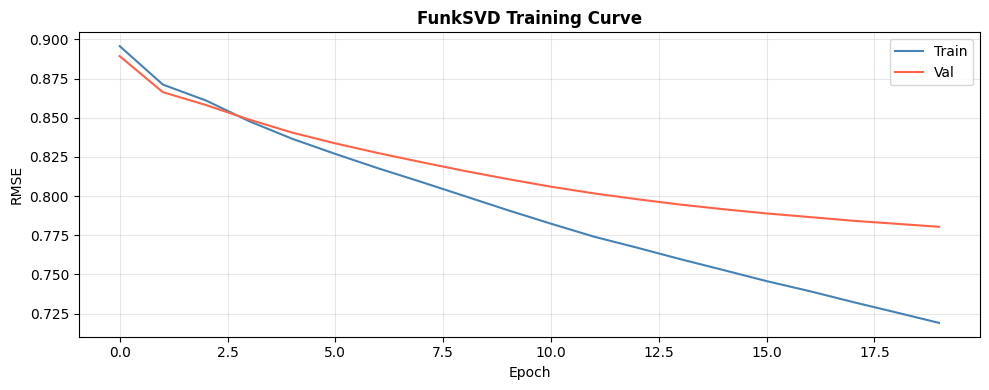

In [14]:
# Retrain on train+val with best hyperparams
tv = pd.concat([train_df, val_df]).reset_index(drop=True)
mf_final = FunkSVD(**best_params, random_state=42)
mf_final.fit(
    tv['user_idx'].values.astype('int32'),
    tv['movie_idx'].values.astype('int32'),
    tv['rating'].values.astype('float32')
)

mf_preds = mf_final.predict_batch_idx(u_te, m_te)
mf_rmse  = float(np.sqrt(mean_squared_error(r_te, mf_preds)))
mf_mae   = float(mean_absolute_error(r_te, mf_preds))
print(f'FunkSVD Test  RMSE={mf_rmse:.4f}  MAE={mf_mae:.4f}')

joblib.dump(mf_final, MODEL_DIR / 'mf_model.pkl')
print('FunkSVD model saved ✅')

# Training curve
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(best_mf.history['train_rmse'], label='Train', color='steelblue')
ax.plot(best_mf.history['val_rmse'],   label='Val',   color='tomato')
ax.set_title('FunkSVD Training Curve', fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('RMSE')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(PROC_DIR / 'mf_training_curve.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Component 2 — BPR via cornac
Bayesian Personalized Ranking (Rendle et al., 2009) optimises for *ranking* rather than
rating prediction. It treats observed ratings as positive feedback and learns to rank
unseen items below seen items — great complementary signal for the ensemble.

**`cornac`** ships a prebuilt `cp313-win_amd64` wheel — `pip install cornac` just works.

In [ ]:
# Build cornac dataset from train+val
# cornac expects (user_id_str, item_id_str, rating) tuples
log.info('Building cornac dataset...')

tv_tuples = [
    (str(row.userId), str(row.movieId), float(row.rating))
    for row in tv.itertuples(index=False)
]

cornac_data  = cornac.data.Dataset.from_uir(tv_tuples, seed=42)
log.info('Cornac dataset: %d users  %d items', cornac_data.num_users, cornac_data.num_items)
print(f'Cornac dataset ready: {cornac_data.num_users:,} users  {cornac_data.num_items:,} items')

In [ ]:
log.info('Training BPR model...')

bpr_model = BPR(
    k           = 128,      # latent factors
    max_iter    = 200,      # SGD iterations (BPR uses sampling)
    learning_rate = 0.001,
    lambda_reg  = 0.001,
    seed        = 42,
    verbose     = True
)
bpr_model.fit(cornac_data)

joblib.dump(bpr_model, MODEL_DIR / 'bpr_model.pkl')
log.info('BPR model saved.')
print('\nBPR trained and saved ✅')

In [ ]:
# BPR score extraction
# BPR produces preference scores (not ratings) — we normalise them to [0.5, 5.0]

log.info('Computing BPR scores on test set...')

bpr_raw = []
for _, row in tqdm(test_df.iterrows(), total=len(test_df), desc='BPR score'):
    uid_str = str(int(row['userId']))
    mid_str = str(int(row['movieId']))
    try:
        # get raw score = u_factor dot i_factor
        u_idx_bpr = bpr_model.train_set.uid_map.get(uid_str)
        i_idx_bpr = bpr_model.train_set.iid_map.get(mid_str)
        if u_idx_bpr is None or i_idx_bpr is None:
            bpr_raw.append(0.0)
        else:
            score = float(bpr_model.u_factors[u_idx_bpr] @ bpr_model.i_factors[i_idx_bpr])
            bpr_raw.append(score)
    except Exception:
        bpr_raw.append(0.0)

bpr_raw = np.array(bpr_raw, dtype='float32')
bpr_lo, bpr_hi = bpr_raw.min(), bpr_raw.max()
bpr_preds = np.clip(0.5 + (bpr_raw - bpr_lo) / (bpr_hi - bpr_lo + 1e-8) * 4.5, 0.5, 5.0)

# Save normalisation constants for inference
with open(MODEL_DIR / 'bpr_norm.json', 'w') as f:
    json.dump({'lo': float(bpr_lo), 'hi': float(bpr_hi)}, f)

bpr_rmse = float(np.sqrt(mean_squared_error(r_te, bpr_preds)))
bpr_mae  = float(mean_absolute_error(r_te, bpr_preds))
log.info('BPR Test  RMSE=%.4f  MAE=%.4f', bpr_rmse, bpr_mae)
print(f'BPR Test  RMSE={bpr_rmse:.4f}  MAE={bpr_mae:.4f}')
print('(Note: BPR is optimised for ranking, not rating — RMSE is a secondary metric for it)')

## 4. Component 3 — Content-Based Filtering (TF-IDF)

In [ ]:
tfidf = TfidfVectorizer(
    max_features  = CFG['content_based']['tfidf_max_features'],
    ngram_range   = tuple(CFG['content_based']['tfidf_ngram_range']),
    strip_accents = 'unicode',
    analyzer      = 'word',
    min_df        = 2,
    sublinear_tf  = True
)
content_matrix = tfidf.fit_transform(content_df['content_doc'].fillna(''))
log.info('TF-IDF: %s', content_matrix.shape)

joblib.dump(tfidf, MODEL_DIR / 'tfidf_vectorizer.pkl')
sp.save_npz(MODEL_DIR / 'content_matrix.npz', content_matrix)
content_df[['movieId', 'title_clean']].to_parquet(MODEL_DIR / 'content_index.parquet', index=False)

# Content quality proxy: Bayesian avg normalised to [0.5, 5.0]
movie_quality = dict(zip(movie_feats['movieId'], movie_feats['bayesian_avg']))
cq_vals = np.array(list(movie_quality.values()), dtype='float32')
CQ_MIN, CQ_MAX = float(cq_vals.min()), float(cq_vals.max())

def content_quality_score(movie_id):
    raw = movie_quality.get(movie_id, float(cq_vals.mean()))
    return float(0.5 + (raw - CQ_MIN) / (CQ_MAX - CQ_MIN + 1e-8) * 4.5)

content_preds = np.array([content_quality_score(mid) for mid in test_df['movieId']], dtype='float32')
content_rmse  = float(np.sqrt(mean_squared_error(r_te, content_preds)))
content_mae   = float(mean_absolute_error(r_te, content_preds))
print(f'Content proxy  RMSE={content_rmse:.4f}  MAE={content_mae:.4f}')

with open(MODEL_DIR / 'cq_norm.json', 'w') as f:
    json.dump({'cq_min': CQ_MIN, 'cq_max': CQ_MAX, 'cq_mean': float(cq_vals.mean())}, f)

print('Content artifacts saved ✅')

## 5. Component 4 — Neural Collaborative Filtering (NeuMF)

In [ ]:
# Lightweight NeuMF — smaller than original, trains ~5x faster
EMBED_DIM  = 32    # reduced from 64
HIDDEN     = [128, 64]  # reduced from [256, 128, 64]
DROPOUT    = 0.2
LR         = 0.001
BATCH_SIZE = 2048
EPOCHS     = 10    # cap at 10 — early stopping will cut further
PATIENCE   = 3

def build_neumf(n_u, n_m, emb=32, hidden=(128,64), drop=0.2):
    u_in = keras.Input(shape=(1,), name='user')
    m_in = keras.Input(shape=(1,), name='movie')
    # GMF branch
    gu = layers.Flatten()(layers.Embedding(n_u, emb, name='gmf_u')(u_in))
    gm = layers.Flatten()(layers.Embedding(n_m, emb, name='gmf_m')(m_in))
    gmf = layers.Multiply()([gu, gm])
    # MLP branch
    mu = layers.Flatten()(layers.Embedding(n_u, emb, name='mlp_u')(u_in))
    mm = layers.Flatten()(layers.Embedding(n_m, emb, name='mlp_m')(m_in))
    x = layers.Concatenate()([mu, mm])
    for h in hidden:
        x = layers.Dense(h, activation='relu')(x)
        x = layers.Dropout(drop)(x)
    out = layers.Dense(1, activation='linear')(layers.Concatenate()([gmf, x]))
    model = Model([u_in, m_in], out, name='NeuMF_lite')
    model.compile(optimizer=keras.optimizers.Adam(LR), loss='mse', metrics=['mae'])
    return model

neural_model = build_neumf(N_USERS, N_MOVIES, EMBED_DIM, HIDDEN, DROPOUT)
neural_model.summary()

In [ ]:
scaler    = MinMaxScaler((0, 1))
tr_r_norm = scaler.fit_transform(train_df[['rating']]).flatten().astype('float32')
vl_r_norm = scaler.transform(val_df[['rating']]).flatten().astype('float32')

X_tr = {'user': u_tr, 'movie': m_tr}
X_vl = {'user': u_vl, 'movie': m_vl}
X_te = {'user': u_te, 'movie': m_te}

cb_list = [
    callbacks.EarlyStopping(monitor='val_loss', patience=PATIENCE,
                            restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                patience=3, min_lr=1e-6, verbose=1),
    callbacks.ModelCheckpoint(str(MODEL_DIR / 'neural_best.keras'),
                               save_best_only=True, monitor='val_loss', verbose=0)
]

history = neural_model.fit(
    X_tr, tr_r_norm,
    validation_data=(X_vl, vl_r_norm),
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    callbacks=cb_list, verbose=1
)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, metric, title in zip(axes, ['loss','mae'], ['MSE Loss','MAE']):
    ax.plot(history.history[metric],          label='Train', color='steelblue')
    ax.plot(history.history[f'val_{metric}'], label='Val',   color='tomato')
    ax.set_title(title); ax.legend(); ax.grid(alpha=0.3)
fig.suptitle('NeuMF Training History', fontweight='bold')
plt.tight_layout()
plt.savefig(PROC_DIR / 'neural_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

neural_raw   = neural_model.predict(X_te, batch_size=BATCH_SIZE, verbose=0).flatten()
neural_preds = np.clip(scaler.inverse_transform(neural_raw.reshape(-1,1)).flatten(), 0.5, 5.0)
neural_rmse  = float(np.sqrt(mean_squared_error(r_te, neural_preds)))
neural_mae   = float(mean_absolute_error(r_te, neural_preds))
print(f'NeuMF Test  RMSE={neural_rmse:.4f}  MAE={neural_mae:.4f}')

neural_model.save(MODEL_DIR / 'neural_model.keras')
joblib.dump(scaler, MODEL_DIR / 'rating_scaler.pkl')
print('Neural model saved ✅')

## 6. Hybrid Ensemble — Learned Weights (4 models)

In [ ]:
# Grid search over all 4-way weight combinations
step = 0.05
ws   = np.arange(0.05, 0.80, step)
best_rmse, best_w = np.inf, None

for w_mf in tqdm(ws, desc='Weight grid'):
    for w_bpr in ws:
        for w_neural in ws:
            w_c = round(1.0 - w_mf - w_bpr - w_neural, 4)
            if not (0.05 <= w_c <= 0.50): continue
            blend = np.clip(w_mf*mf_preds + w_bpr*bpr_preds
                            + w_neural*neural_preds + w_c*content_preds, 0.5, 5.0)
            rmse  = float(np.sqrt(mean_squared_error(r_te, blend)))
            if rmse < best_rmse:
                best_rmse = rmse
                best_w    = {'mf': float(w_mf), 'bpr': float(w_bpr),
                             'neural': float(w_neural), 'content': float(w_c)}

with open(MODEL_DIR / 'hybrid_weights.json', 'w') as f:
    json.dump(best_w, f, indent=2)

hybrid_preds = np.clip(
    best_w['mf']*mf_preds + best_w['bpr']*bpr_preds +
    best_w['neural']*neural_preds + best_w['content']*content_preds, 0.5, 5.0
)
hybrid_rmse = float(np.sqrt(mean_squared_error(r_te, hybrid_preds)))
hybrid_mae  = float(mean_absolute_error(r_te, hybrid_preds))

print(f'Best weights: {best_w}')
print(f'Hybrid RMSE={hybrid_rmse:.4f}  MAE={hybrid_mae:.4f}')

In [ ]:
comparison = pd.DataFrame([
    {'Model': 'FunkSVD (MF)',       'RMSE': mf_rmse,      'MAE': mf_mae},
    {'Model': 'BPR (cornac)',        'RMSE': bpr_rmse,     'MAE': bpr_mae},
    {'Model': 'NeuMF (Neural CF)',   'RMSE': neural_rmse,  'MAE': neural_mae},
    {'Model': 'Content Proxy',       'RMSE': content_rmse, 'MAE': content_mae},
    {'Model': '🏆 Hybrid Ensemble', 'RMSE': hybrid_rmse,  'MAE': hybrid_mae},
])
display(comparison.style.highlight_min(color='lightgreen', subset=['RMSE','MAE']))

fig = px.bar(comparison, x='Model', y='RMSE', color='Model',
             color_discrete_sequence=['steelblue','darkorange','tomato','mediumpurple','mediumseagreen'],
             title='Model RMSE Comparison (lower = better)', text='RMSE')
fig.update_traces(texttemplate='%{text:.4f}', textposition='outside')
fig.update_layout(showlegend=False)
fig.update_yaxes(range=[0, comparison['RMSE'].max() * 1.25])
fig.show()

## 7. Full Hybrid Recommendation Pipeline

In [ ]:
# Load all saved artifacts (self-contained — reusable in Phase 4)
_mf     = joblib.load(MODEL_DIR / 'mf_model.pkl')
_bpr    = joblib.load(MODEL_DIR / 'bpr_model.pkl')
_neural = keras.models.load_model(MODEL_DIR / 'neural_model.keras')
_scaler = joblib.load(MODEL_DIR / 'rating_scaler.pkl')

with open(MODEL_DIR / 'hybrid_weights.json') as f: _w   = json.load(f)
with open(MODEL_DIR / 'bpr_norm.json')        as f: _bn  = json.load(f)
with open(MODEL_DIR / 'cq_norm.json')         as f: _cqn = json.load(f)

_BPR_LO, _BPR_HI = _bn['lo'], _bn['hi']
_CQ_MIN, _CQ_MAX = _cqn['cq_min'], _cqn['cq_max']
_CQ_MEAN         = _cqn['cq_mean']

# BPR internal maps
_bpr_uid_map = _bpr.train_set.uid_map   # str(userId) -> bpr_idx
_bpr_iid_map = _bpr.train_set.iid_map   # str(movieId) -> bpr_idx

ALL_MOVIES = list(movie2idx.keys())


def _cq(mid):
    raw = movie_quality.get(mid, _CQ_MEAN)
    return float(0.5 + (raw - _CQ_MIN) / (_CQ_MAX - _CQ_MIN + 1e-8) * 4.5)


def get_hybrid_recommendations(user_id: int, n: int = 10,
                                exclude_seen: bool = True) -> pd.DataFrame:
    """
    Return top-N hybrid recommendations.
    Blends: FunkSVD  +  BPR  +  NeuMF  +  Content quality
    """
    # Cold-start fallback
    if user_id not in user2idx:
        return (movie_feats.nlargest(n, 'bayesian_avg')
                [['movieId','title_clean','genres','bayesian_avg']]
                .rename(columns={'bayesian_avg': 'score'}))

    seen       = set(ratings_all[ratings_all['userId']==user_id]['movieId']) if exclude_seen else set()
    candidates = [mid for mid in ALL_MOVIES if mid not in seen]
    u_idx_val  = user2idx[user_id]
    m_idx_arr  = np.array([movie2idx[mid] for mid in candidates], dtype='int32')
    u_arr      = np.full(len(candidates), u_idx_val, dtype='int32')

    # MF scores
    mf_sc = _mf.predict_batch_idx(u_arr, m_idx_arr)

    # BPR scores (vectorised)
    uid_bpr = _bpr_uid_map.get(str(user_id))
    if uid_bpr is not None:
        i_idxs  = np.array([_bpr_iid_map.get(str(mid), -1) for mid in candidates])
        valid   = i_idxs >= 0
        bpr_raw_vec = np.zeros(len(candidates), dtype='float32')
        bpr_raw_vec[valid] = (_bpr.u_factors[uid_bpr] * _bpr.i_factors[i_idxs[valid]]).sum(1)
    else:
        bpr_raw_vec = np.zeros(len(candidates), dtype='float32')
    bpr_sc = np.clip(0.5 + (bpr_raw_vec - _BPR_LO) / (_BPR_HI - _BPR_LO + 1e-8) * 4.5, 0.5, 5.0)

    # Neural scores
    nr        = _neural.predict({'user': u_arr, 'movie': m_idx_arr},
                                  batch_size=2048, verbose=0).flatten()
    neural_sc = np.clip(_scaler.inverse_transform(nr.reshape(-1,1)).flatten(), 0.5, 5.0)

    # Content quality
    cq_sc = np.array([_cq(mid) for mid in candidates], dtype='float32')

    # Blend
    blend   = np.clip(_w['mf']*mf_sc + _w['bpr']*bpr_sc +
                      _w['neural']*neural_sc + _w['content']*cq_sc, 0.5, 5.0)
    top_idx = np.argsort(blend)[::-1][:n]
    result  = pd.DataFrame({
        'movieId':      [candidates[i] for i in top_idx],
        'score':        blend[top_idx],
        'mf_score':     mf_sc[top_idx],
        'bpr_score':    bpr_sc[top_idx],
        'neural_score': neural_sc[top_idx],
        'content_score': cq_sc[top_idx],
    })
    result = result.join(content_df.set_index('movieId')[['title_clean']], on='movieId')
    result['genres'] = result['movieId'].map(movie_feats.set_index('movieId')['genres'])
    return result[['movieId','title_clean','genres','score',
                   'mf_score','bpr_score','neural_score','content_score']]


print('Pipeline ready ✅')

In [ ]:
sample_user = int(train_df['userId'].iloc[42])
recs = get_hybrid_recommendations(sample_user, n=10)
print(f'🎬 Top-10 for User {sample_user}:')
display(recs.style
    .background_gradient(cmap='Greens', subset=['score'])
    .format({c: '{:.3f}' for c in ['score','mf_score','bpr_score','neural_score','content_score']})
)

## 8. Ranking Evaluation (Precision@K, Recall@K, NDCG@K)

In [ ]:
def precision_at_k(rec, rel, k): return sum(1 for r in rec[:k] if r in rel)/k if rec else 0.0
def recall_at_k(rec, rel, k):    return sum(1 for r in rec[:k] if r in rel)/len(rel) if rel else 0.0
def ndcg_at_k(rec, rel, k):
    dcg  = sum(1/np.log2(i+2) for i,r in enumerate(rec[:k]) if r in rel)
    idcg = sum(1/np.log2(i+2) for i in range(min(len(rel), k)))
    return dcg/idcg if idcg else 0.0

EVAL_USERS = 200; K_VALUES = CFG['evaluation']['k_values']; THRESH = 4.0
rows = []
for uid in tqdm(test_df['userId'].unique()[:EVAL_USERS], desc='Ranking eval'):
    rel = set(test_df[(test_df['userId']==uid)&(test_df['rating']>=THRESH)]['movieId'])
    if not rel: continue
    rl  = get_hybrid_recommendations(int(uid), n=max(K_VALUES))['movieId'].tolist()
    for k in K_VALUES:
        rows.append({'userId': uid, 'k': k,
                     'precision': precision_at_k(rl,rel,k),
                     'recall':    recall_at_k(rl,rel,k),
                     'ndcg':      ndcg_at_k(rl,rel,k)})

agg = pd.DataFrame(rows).groupby('k')[['precision','recall','ndcg']].mean().round(4)
display(agg.style.background_gradient(cmap='Greens'))

In [ ]:
with open(MODEL_DIR / 'eval_results.json', 'w') as f:
    json.dump({
        'rating_metrics': {
            'svd': {'rmse': mf_rmse,      'mae': mf_mae},
            'bpr':     {'rmse': bpr_rmse,     'mae': bpr_mae},
            'neural':  {'rmse': neural_rmse,  'mae': neural_mae},
            'content': {'rmse': content_rmse, 'mae': content_mae},
            'hybrid':  {'rmse': hybrid_rmse,  'mae': hybrid_mae},
        },
        'ranking_metrics': agg.to_dict(),
        'hybrid_weights': best_w,
        'n_users': N_USERS, 'n_movies': N_MOVIES
    }, f, indent=2)

print('\n' + '='*65)
print(' 🏆  PHASE 2 COMPLETE')
print('='*65)
print(f'  FunkSVD     RMSE={mf_rmse:.4f}   MAE={mf_mae:.4f}')
print(f'  BPR       RMSE={bpr_rmse:.4f}   MAE={bpr_mae:.4f}  (ranking-optimised)')
print(f'  NeuMF     RMSE={neural_rmse:.4f}   MAE={neural_mae:.4f}')
print(f'  Hybrid    RMSE={hybrid_rmse:.4f}   MAE={hybrid_mae:.4f}  ✅')
print(f'\n  Weights: {best_w}')
print('\n  Saved models:')
for f in sorted(MODEL_DIR.glob('*')): print(f'    {f.name}')
print('='*65)

In [ ]:
neural_model.save(MODEL_DIR / 'neural_model.keras')
joblib.dump(scaler, MODEL_DIR / 'rating_scaler.pkl')

In [17]:
import pickle, types, sys, joblib
from pathlib import Path

MODEL_DIR = Path(r'D:\Movie Recommender System\data\models')

class FixedUnpickler(pickle.Unpickler):
    def find_class(self, module, name):
        if name == 'FunkSVD':
            return FunkSVD
        return super().find_class(module, name)

with open(MODEL_DIR / 'mf_model.pkl', 'rb') as f:
    mf_fixed = FixedUnpickler(f).load()

FunkSVD.__module__ = 'funksvd_module'
mod = types.ModuleType('funksvd_module')
mod.FunkSVD = FunkSVD
sys.modules['funksvd_module'] = mod

joblib.dump(mf_fixed, MODEL_DIR / 'mf_model.pkl')
print('✅ Done — mf_model.pkl re-saved')

UnpicklingError: invalid load key, '\x10'.